# 06 — Fine-tuning & Evaluation on Field Recordings

Adapt the trained model to real-world microphone recordings collected across three field sessions, then evaluate classification performance on those recordings.

### Approach

The backbone (convolutional feature extractor) is frozen. Only the classifier head is re-trained on the field data. This limits overfitting given the small number of field examples and preserves the acoustic representations learned during pre-training.

- Confidence-weighted voting (`confidence_power = 2`): sliding windows that are uncertain contribute less to the final prediction
- Augmentation for under-represented classes (threshold <= 80 examples): BG, Bus, Truck
- Loss weights: inverse-frequency squared on the augmented distribution

**Classes:** BG, MC, Car, Bus, Truck, Tram, Horn, Dog, Construction, Siren


In [2]:
from pathlib import Path
import re, warnings, copy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import Counter

import librosa
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False})
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print(f"PyTorch {torch.__version__} | Librosa {librosa.__version__}")


PyTorch 2.10.0+cpu | Librosa 0.11.0


In [3]:
DIR_AUDIO  = Path("audio")
DIR_05_05  = Path("Enregistrements_05_05_2026_nuageux_h50cm_distance_route_1m")
DIR_30_04  = Path("Enregistrements_30_04")
OUTPUT_DIR = Path("results_eval"); OUTPUT_DIR.mkdir(exist_ok=True)
CKPT_PATH  = Path("checkpoints/logmel_best-v1.ckpt")
STATS_PATH = Path("data/norm_stats_logmel.npz")
MANIFEST   = Path("data/features_manifest.csv")

CLASS2IDX = {'BG':0,'MC':1,'Car':2,'Bus':3,'Truck':4,
             'Tram':5,'Horn':6,'Dog':7,'Construction':8,'Siren':9}
IDX2CLASS  = {v:k for k,v in CLASS2IDX.items()}
CLASSES    = list(CLASS2IDX.keys()); N_CLASSES = len(CLASSES)
BG_IDX     = CLASS2IDX['BG']

LABEL_MAP = {
    'voiture':'Car','voitures':'Car','2voitures':'Car','plusieurs_voitures':'Car',
    'car':'Car','3cars':'Car','car2':'Car','car3':'Car','car4':'Car','car5':'Car',
    'rien':'BG','bg':'BG','noaudio':'BG','noaudio1':'BG','noaudio2':'BG',
    'noaudio3':'BG','noaudio4':'BG','electric':'BG','electriccar':'BG',
    'velo':'BG','vélo':'BG','cri_rien':'BG','discussion_rien':'BG',
    'discussions_rien':'BG',
    'bus':'Bus','camion':'Truck','truck':'Truck','moto':'MC',
    'car-bus-car':'MULTI',
}

TARGET_SR      = 22050; TARGET_DUR = 5.0
TARGET_SAMPLES = int(TARGET_SR * TARGET_DUR)
N_FFT=1024; HOP_LENGTH=512; N_MELS=64; FMIN=50; FMAX=8000; T_FRAMES=216

# Fine-tuning
FT_LR=1e-4; FT_MAX_EPOCHS=40; FT_BATCH_SIZE=8; FT_PATIENCE=10

# Augmentation -- threshold applied to all under-represented classes (including BG)
AUG_THRESHOLD  = 80   # classes with < 80 examples are augmented
AUG_MULTIPLIER = 2    # x2 -- moderate enough not to over-weight augmented classes

# VAD
VAD_ENERGY_PERCENTILE = 20
VAD_WINDOW_PERCENTILE = 30

# Confidence-weighted voting (no BG override)
CONFIDENCE_POWER = 2.0

for d in [DIR_AUDIO, DIR_05_05, DIR_30_04, CKPT_PATH, STATS_PATH]:
    assert d.exists(), f"[fail] Not found: {d}"
print("Configuration OK")
print(f"   AUG_THRESHOLD  : {AUG_THRESHOLD}  (BG + Bus + Truck augmented)")
print(f"   AUG_MULTIPLIER : {AUG_MULTIPLIER}")
print(f"   CONFIDENCE_POWER : {CONFIDENCE_POWER}  (confidence-weighted voting, no override)")


Configuration OK
   AUG_THRESHOLD  : 80  (BG + Bus + Truck augmented)
   AUG_MULTIPLIER : 2
   CONFIDENCE_POWER : 2.0  (confidence-weighted voting, no override)


In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=(2,2)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True), nn.MaxPool2d(pool))
    def forward(self, x): return self.block(x)

class AudioCNN(nn.Module):
    def __init__(self, n_classes=10, dropout=0.5):
        super().__init__()
        self.features   = nn.Sequential(
            ConvBlock(1,32), ConvBlock(32,64), ConvBlock(64,128),
            ConvBlock(128,128), nn.AdaptiveAvgPool2d((4,4)))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout),
            nn.Linear(128*4*4, 256), nn.ReLU(inplace=True),
            nn.Dropout(dropout*0.6), nn.Linear(256, n_classes))
    def forward(self, x): return self.classifier(self.features(x))

class AudioClassifier(pl.LightningModule):
    def __init__(self, n_classes=10, class_weights=None, lr=1e-3, dropout=0.5):
        super().__init__()
        self.save_hyperparameters(ignore=['class_weights'])
        self.model     = AudioCNN(n_classes, dropout)
        self.criterion = nn.CrossEntropyLoss(weight=class_weights)
        self.lr        = lr
    def forward(self, x): return self.model(x)
    def training_step(self, b, _):
        x,y=b; loss=self.criterion(self(x),y); self.log('train_loss',loss); return loss
    def validation_step(self, b, _):
        x,y=b; logits=self(x); loss=self.criterion(logits,y)
        self.log('val_loss',loss); self.log('val_acc',(logits.argmax(1)==y).float().mean())
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
manifest_df  = pd.read_csv(MANIFEST)
train_df     = manifest_df[manifest_df['split']=='train']
label_counts = train_df['label_idx'].value_counts().sort_index()
counts       = torch.tensor(label_counts.values, dtype=torch.float)
weights      = (1.0/counts)/(1.0/counts).mean()

model = AudioClassifier.load_from_checkpoint(
    CKPT_PATH, n_classes=N_CLASSES, class_weights=weights)
model.eval().to(device)

stats = np.load(STATS_PATH)
NORM_MEAN = stats['mean']; NORM_STD = stats['std']
print(f"Model loaded -- {sum(p.numel() for p in model.parameters()):,} params | {device}")


Model loaded -- 767,722 params | cpu


In [5]:
def load_mono(p):
    y,_ = librosa.load(str(p), sr=TARGET_SR, mono=True)
    return y.astype(np.float32)

def center_pad_or_trim(y, n=TARGET_SAMPLES):
    if len(y)==n: return y
    if len(y)<n: p=n-len(y); return np.pad(y,(p//2,p-p//2),mode='constant')
    s=(len(y)-n)//2; return y[s:s+n]

def normalise_rms(y, target_db=-23.0, eps=1e-9):
    return y*(10**(target_db/20)/(np.sqrt(np.mean(y**2))+eps))

def compute_logmel(y):
    S=librosa.feature.melspectrogram(y=y,sr=TARGET_SR,n_fft=N_FFT,
      hop_length=HOP_LENGTH,n_mels=N_MELS,fmin=FMIN,fmax=FMAX,power=2.0)
    return librosa.power_to_db(S,ref=np.max).astype(np.float32)

def spec_to_tensor(spec):
    if spec.shape[1]<T_FRAMES:
        spec=np.pad(spec,((0,0),(0,T_FRAMES-spec.shape[1])),
                    mode='constant',constant_values=spec.min())
    else: spec=spec[:,:T_FRAMES]
    x=torch.from_numpy(spec).to(device)
    x=(x-float(NORM_MEAN.mean()))/(float(NORM_STD.mean())+1e-6)
    return x.unsqueeze(0).unsqueeze(0)

def vad_trim(y, frame_dur=0.05, energy_percentile=20.0, margin_sec=0.25, min_dur=0.5):
    frame_n=max(1,int(frame_dur*TARGET_SR)); n_frames=len(y)//frame_n
    if n_frames<2: return y
    rms=np.array([np.sqrt(np.mean(y[i*frame_n:(i+1)*frame_n]**2)) for i in range(n_frames)])
    active=np.where(rms>=np.percentile(rms,energy_percentile))[0]
    if len(active)==0: return y
    margin=int(margin_sec*TARGET_SR)
    onset =max(0,      int(active[0]*frame_n)      -margin)
    offset=min(len(y), int((active[-1]+1)*frame_n) +margin)
    return y[onset:offset] if (offset-onset)>=int(min_dur*TARGET_SR) else y

print("Audio functions defined")


Audio functions defined


In [6]:
def find_event_boundaries(y, n_events, frame_dur=0.05, smooth_frames=5):
    if n_events==1: return [(0,len(y))]
    frame_n=int(frame_dur*TARGET_SR); n_frames=max(1,len(y)//frame_n)
    rms=np.array([np.sqrt(np.mean(y[i*frame_n:(i+1)*frame_n]**2)) for i in range(n_frames)])
    rms_s=np.convolve(rms,np.ones(smooth_frames)/smooth_frames,mode='same')
    bounds=[0]; radius=int(0.20*n_frames/n_events)
    for k in range(1,n_events):
        c=int(k*n_frames/n_events); lo,hi=max(0,c-radius),min(n_frames-1,c+radius)
        bounds.append(int((lo+np.argmin(rms_s[lo:hi+1]))*frame_n))
    bounds.append(len(y))
    min_s=int(1.0*TARGET_SR); segs=[]
    for i in range(n_events):
        s,e=bounds[i],bounds[i+1]
        if (e-s)<min_s:
            zl=len(y)//n_events
            return [(k*zl,(k+1)*zl if k<n_events-1 else len(y)) for k in range(n_events)]
        segs.append((s,e))
    return segs

test_wav=list(DIR_05_05.glob("*.wav"))[:1]
if test_wav:
    print(f"Segmentation OK | {test_wav[0].name}")


Segmentation OK | bus_20260505_093322.wav


In [7]:
def parse_labels(stem):
    name=re.sub(r'_\d{8}_\d{6}$','',stem.lower())
    name=re.sub(r'_\d+$','',name).replace(' ','')
    if name=='car-bus-car': return ['Car','Bus','Car']
    if name in LABEL_MAP and LABEL_MAP[name]!='MULTI': return [LABEL_MAP[name]]
    parts=re.split(r'_puis_',name); labels=[]
    for part in parts:
        part=part.strip('_'); matched=None
        if part in LABEL_MAP and LABEL_MAP[part]!='MULTI':
            matched=LABEL_MAP[part]
        else:
            for key,cls in LABEL_MAP.items():
                if cls=='MULTI': continue
                if part==key or part.startswith(key+'_') or part.endswith('_'+key):
                    matched=cls; break
        if matched is None and part.capitalize() in CLASS2IDX:
            matched=part.capitalize()
        if matched: labels.append(matched)
        else: print(f"  WARNING: unrecognised label '{part}' in '{stem}'")
    return labels if labels else ['BG']

def build_inventory(directories):
    if isinstance(directories,Path): directories=[directories]
    rows=[]
    for d in directories:
        wavs=sorted(d.glob("*.wav")) or sorted(d.glob("**/*.wav"))
        for wav in wavs:
            labels=parse_labels(wav.stem)
            for ei,cls in enumerate(labels):
                rows.append({'path':str(wav),'stem':wav.stem,'dossier':d.name,
                             'n_events':len(labels),'ev_idx':ei,
                             'true_class':cls,'true_idx':CLASS2IDX[cls]})
    return pd.DataFrame(rows)

df_all = build_inventory([DIR_AUDIO, DIR_05_05, DIR_30_04])
print(f"Inventaire total : {df_all['path'].nunique()} files | {len(df_all)} événements")
print(df_all['true_class'].value_counts().to_string())


Inventaire total : 110 files | 151 événements
true_class
Car      100
BG        41
Bus        5
Truck      5


In [8]:
def extract_logmel_tensor(y_segment):
    y=center_pad_or_trim(normalise_rms(y_segment))
    spec=compute_logmel(y)
    if spec.shape[1]<T_FRAMES:
        spec=np.pad(spec,((0,0),(0,T_FRAMES-spec.shape[1])),
                    mode='constant',constant_values=spec.min())
    else: spec=spec[:,:T_FRAMES]
    x=torch.from_numpy(spec)
    x=(x-float(NORM_MEAN.mean()))/(float(NORM_STD.mean())+1e-6)
    return x.unsqueeze(0)

def augment_audio(y, rng):
    out=y.copy()
    if rng.random()<0.7:
        out=librosa.effects.pitch_shift(out,sr=TARGET_SR,n_steps=rng.uniform(-1.5,1.5))
    if rng.random()<0.7:
        out=librosa.effects.time_stretch(out,rate=rng.uniform(0.88,1.12))
    if rng.random()<0.7:
        rms=np.sqrt(np.mean(out**2))+1e-9
        out=out+(rng.standard_normal(len(out))*(rms/(10**(rng.uniform(20,30)/20)))).astype(np.float32)
    return out.astype(np.float32)

class FineTuneDataset(torch.utils.data.Dataset):
    def __init__(self,items): self.items=items
    def __len__(self): return len(self.items)
    def __getitem__(self,i):
        x,y=self.items[i]; return x,torch.tensor(y,dtype=torch.long)

def build_raw_segments(df):
    raw={}; errors=[]
    for wav_path,grp in df.groupby('path'):
        try: y=load_mono(wav_path)
        except Exception as e: errors.append(str(e)); continue
        segs=find_event_boundaries(y,grp['n_events'].iloc[0])
        for _,row in grp.iterrows():
            ei=row['ev_idx']
            if ei>=len(segs): continue
            s,e=segs[ei]; seg=y[s:e]
            if len(seg)<int(0.5*TARGET_SR): continue
            raw.setdefault(row['true_idx'],[]).append(seg)
    return raw,errors

def segments_to_items(raw_segments, rng, aug_threshold=AUG_THRESHOLD,
                      aug_multiplier=AUG_MULTIPLIER, verbose=True):
    """
    Augmente toutes les classes avec < aug_threshold exemples.
    BG est maintenant augmented au même titre que Bus et Truck.
    """
    items=[]
    for idx,segs in raw_segments.items():
        cls=IDX2CLASS[idx]
        for seg in segs: items.append((extract_logmel_tensor(seg),idx))
        if len(segs)<aug_threshold:
            n_aug=aug_multiplier*len(segs)
            if verbose:
                print(f"  Augment {cls:<12}: {len(segs):>3} -> {len(segs)+n_aug}")
            for k in range(n_aug):
                items.append((extract_logmel_tensor(
                    augment_audio(segs[k%len(segs)],rng)),idx))
    return items

print("Dataset functions defined")


Dataset functions defined


In [9]:
def run_finetune(train_items, val_items, base_model, verbose=True):
    """
    Backbone fully frozen; only the classifier head is trained.
    Loss weights: inverse-frequency squared on the augmented distribution,
    capped at x50 so BG receives a fair weight relative to Car.
    """
    ft_model=copy.deepcopy(base_model); ft_model.to(device)
    for p in ft_model.model.features.parameters():   p.requires_grad=False
    for p in ft_model.model.classifier.parameters(): p.requires_grad=True

    cc=Counter(y for _,y in train_items)
    ft_c=torch.zeros(N_CLASSES)
    for idx,cnt in cc.items(): ft_c[idx]=cnt
    safe=ft_c.clone(); safe[safe==0]=1e9
    raw_w=(1.0/safe**2)
    # Normalise relative to the median class (more stable than min)
    ref=raw_w[ft_c>0].median()
    raw_w=(raw_w/ref).clamp(max=50.0)
    ft_weights=raw_w.to(device)

    if verbose:
        print("Class weights:")
        for i,(w,cnt) in enumerate(zip(ft_weights.cpu(),ft_c)):
            if cnt>0: print(f"  {IDX2CLASS[i]:<12} n={int(cnt):>3}  w={w:.2f}")

    criterion=nn.CrossEntropyLoss(weight=ft_weights)
    optimizer=torch.optim.Adam(
        filter(lambda p:p.requires_grad,ft_model.parameters()),lr=FT_LR)
    scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,mode='max',factor=0.5,patience=4)

    ds_tr=FineTuneDataset(train_items); ds_va=FineTuneDataset(val_items)
    dl_tr=DataLoader(ds_tr,batch_size=FT_BATCH_SIZE,shuffle=True, num_workers=0)
    dl_va=DataLoader(ds_va,batch_size=FT_BATCH_SIZE,shuffle=False,num_workers=0)

    history=[]; best_bal=0.0; best_state=None; patience_cnt=0

    for epoch in range(1,FT_MAX_EPOCHS+1):
        ft_model.train(); train_loss=0.0
        for xb,yb in dl_tr:
            xb,yb=xb.to(device),yb.to(device)
            optimizer.zero_grad(); loss=criterion(ft_model(xb),yb)
            loss.backward(); optimizer.step()
            train_loss+=loss.item()*len(xb)
        train_loss/=len(ds_tr)

        ft_model.eval(); preds,trues=[],[]
        with torch.no_grad():
            for xb,yb in dl_va:
                preds.extend(ft_model(xb.to(device)).argmax(1).cpu().tolist())
                trues.extend(yb.tolist())

        val_acc=accuracy_score(trues,preds)
        val_bal=balanced_accuracy_score(trues,preds)
        scheduler.step(val_bal)
        history.append({'epoch':epoch,'train_loss':train_loss,
                        'val_acc':val_acc,'val_bal_acc':val_bal})

        if val_bal>best_bal:
            best_bal=val_bal; best_state=copy.deepcopy(ft_model.state_dict())
            patience_cnt=0
            if verbose: print(f"  Epoch {epoch:02d} | loss={train_loss:.4f} | "
                              f"val_acc={val_acc:.1%} | bal_acc={val_bal:.1%}  [best]")
        else:
            patience_cnt+=1
            if verbose and epoch%5==0:
                print(f"  Epoch {epoch:02d} | loss={train_loss:.4f} | "
                      f"val_acc={val_acc:.1%} | bal_acc={val_bal:.1%} "
                      f"(patience {patience_cnt}/{FT_PATIENCE})")
            if patience_cnt>=FT_PATIENCE:
                if verbose: print(f"  Early stopping at epoch {epoch}")
                break

    ft_model.load_state_dict(best_state); ft_model.eval()
    return ft_model, history, best_bal

print("run_finetune defined")


run_finetune defined


In [10]:
@torch.no_grad()
def predict_single(y_segment, ft_model, win_dur=2.0, step_dur=0.5):
    """
    Inference -- confidence-weighted voting, no BG override.

    Pipeline:
    1. RMS normalisation
    2. VAD trim (percentile 20, margin 0.25s)
    3. Sliding window 2s / step 0.5s
    4. VAD filter on windows (percentile VAD_WINDOW_PERCENTILE)
    5. Softmax per active window
    6. Weighted vote: weight = max_prob^CONFIDENCE_POWER
       high-confidence windows dominate, uncertain ones are down-weighted
    """
    yn=normalise_rms(y_segment)
    yn=vad_trim(yn, energy_percentile=VAD_ENERGY_PERCENTILE, margin_sec=0.25)

    win_n=int(win_dur*TARGET_SR); step_n=int(step_dur*TARGET_SR)
    windows=[center_pad_or_trim(yn[s:s+win_n])
             for s in range(0,max(1,len(yn)-win_n+1),step_n)]
    if not windows: windows=[center_pad_or_trim(yn)]

    rms_vals=np.array([np.sqrt(np.mean(w**2)) for w in windows])
    thr=np.percentile(rms_vals,VAD_WINDOW_PERCENTILE)
    active=[w for w,r in zip(windows,rms_vals) if r>=thr]
    if not active: active=[windows[int(np.argmax(rms_vals))]]

    all_probs=[]
    for crop in active:
        logits=ft_model(spec_to_tensor(compute_logmel(crop))).cpu().numpy()[0]
        exp_l=np.exp(logits-logits.max()); all_probs.append(exp_l/exp_l.sum())

    all_probs=np.array(all_probs)                     # (N_windows, N_classes)
    weights_v=all_probs.max(axis=1)**CONFIDENCE_POWER    # per-window weight
    weights_v/=weights_v.sum()+1e-9
    return np.einsum('i,ij->j', weights_v, all_probs)   # weighted average


def evaluate_on_df(df_eval_input, ft_model):
    rows=[]
    for wav_path,grp in df_eval_input.groupby('path'):
        try: y=load_mono(wav_path)
        except Exception as e: print(f"[error] {Path(wav_path).name}: {e}"); continue
        segs=find_event_boundaries(y,grp['n_events'].iloc[0])
        for _,row in grp.iterrows():
            ei=row['ev_idx']
            if ei>=len(segs): continue
            s,e=segs[ei]; probs=predict_single(y[s:e],ft_model)
            pred_i=int(np.argmax(probs))
            rows.append({'file':Path(wav_path).name,'ev_idx':ei+1,
                         'true_class':row['true_class'],'true_idx':row['true_idx'],
                         'pred_class':IDX2CLASS[pred_i],'pred_idx':pred_i,
                         'correct':(pred_i==row['true_idx']),
                         'confidence':float(probs.max()),
                         'prob_BG':float(probs[BG_IDX]),
                         'prob_Car':float(probs[CLASS2IDX['Car']]),
                         'prob_Bus':float(probs[CLASS2IDX['Bus']]),
                         'prob_Truck':float(probs[CLASS2IDX['Truck']])})
    return pd.DataFrame(rows)


def print_results(df_r, title=""):
    y_true=df_r['true_idx'].values; y_pred=df_r['pred_idx'].values
    acc=accuracy_score(y_true,y_pred); bal=balanced_accuracy_score(y_true,y_pred)
    print(f"\n{'='*60}\n{title}\n{'='*60}")
    print(f"  Accuracy : {acc:.1%} ({df_r['correct'].sum()}/{len(df_r)}) | Balanced : {bal:.1%}")
    present=sorted(df_r['true_idx'].unique()); names=[IDX2CLASS[i] for i in present]
    for cls in names:
        sub=df_r[df_r['true_class']==cls]; a=sub['correct'].mean()
        flag=''
        print(f"    {cls:<12} {a:>5.0%}  (n={len(sub)}){flag}")
    print()
    print(classification_report(y_true,y_pred,labels=present,
          target_names=names,digits=3,zero_division=0))
    return acc, bal

print("predict_single / evaluate_on_df / print_results defined")


predict_single / evaluate_on_df / print_results defined


## Fine-tuning


In [11]:
rng = np.random.default_rng(SEED)
raw, errors = build_raw_segments(df_all)
print(f"Raw segments: {sum(len(v) for v in raw.values())} | errors: {len(errors)}")
print("Raw distribution:")
for idx,segs in sorted(raw.items()):
    flag=' <- will be augmented' if len(segs)<AUG_THRESHOLD else ''
    print(f"  {IDX2CLASS[idx]:<12} : {len(segs)}{flag}")

print(f"\nAugmentation (threshold={AUG_THRESHOLD}, x{AUG_MULTIPLIER})...")
items = segments_to_items(raw, rng, verbose=True)

class_counts = Counter(lbl for _,lbl in items)
print(f"\n{len(items)} spectrograms total after augmentation")
print("Final distribution:")
for idx,cnt in sorted(class_counts.items()):
    print(f"  {IDX2CLASS[idx]:<12} : {cnt}")

# Split stratifié 80/20
labels_all=[y for _,y in items]
try:
    idx_tr,idx_va=train_test_split(list(range(len(items))),
                                   test_size=0.2,stratify=labels_all,random_state=SEED)
except ValueError:
    idx_tr,idx_va=train_test_split(list(range(len(items))),test_size=0.2,random_state=SEED)

train_items=[items[i] for i in idx_tr]; val_items=[items[i] for i in idx_va]
print(f"\nTrain: {len(train_items)} | Val: {len(val_items)}")
print("Val distribution:")
val_dist=Counter(y for _,y in val_items)
for idx,cnt in sorted(val_dist.items()):
    print(f"  {IDX2CLASS[idx]:<12} : {cnt}")


Raw segments: 151 | errors: 0
Raw distribution:
  BG           : 41 <- will be augmented
  Car          : 100
  Bus          : 5 <- will be augmented
  Truck        : 5 <- will be augmented

Augmentation (threshold=80, x2)...
  Augment Bus         :   5 -> 15
  Augment Truck       :   5 -> 15
  Augment BG          :  41 -> 123

253 spectrograms total after augmentation
Final distribution:
  BG           : 123
  Car          : 100
  Bus          : 15
  Truck        : 15

Train: 202 | Val: 51
Val distribution:
  BG           : 25
  Car          : 20
  Bus          : 3
  Truck        : 3


In [12]:
print(f"Fine-tuning -- max {FT_MAX_EPOCHS} epochs | lr={FT_LR} | patience={FT_PATIENCE}")
print("─"*65)
ft_model, history, best_bal = run_finetune(train_items, val_items, model, verbose=True)
print(f"\nBest val balanced accuracy: {best_bal:.1%}")


Fine-tuning -- max 40 epochs | lr=0.0001 | patience=10
─────────────────────────────────────────────────────────────────
Class weights:
  BG           n= 98  w=0.67
  Car          n= 80  w=1.00
  Bus          n= 12  w=44.44
  Truck        n= 12  w=44.44
  Epoch 01 | loss=11.1865 | val_acc=17.6% | bal_acc=10.2%  [best]
  Epoch 02 | loss=8.5950 | val_acc=25.5% | bal_acc=15.2%  [best]
  Epoch 03 | loss=7.4156 | val_acc=33.3% | bal_acc=20.0%  [best]
  Epoch 04 | loss=4.7996 | val_acc=47.1% | bal_acc=42.2%  [best]
  Epoch 05 | loss=3.9720 | val_acc=54.9% | bal_acc=46.7%  [best]
  Epoch 06 | loss=2.9900 | val_acc=60.8% | bal_acc=64.3%  [best]
  Epoch 07 | loss=3.3375 | val_acc=66.7% | bal_acc=67.6%  [best]
  Epoch 09 | loss=1.9881 | val_acc=70.6% | bal_acc=69.6%  [best]
  Epoch 10 | loss=1.7970 | val_acc=68.6% | bal_acc=68.8% (patience 1/10)


  Epoch 12 | loss=1.4676 | val_acc=70.6% | bal_acc=77.2%  [best]
  Epoch 15 | loss=1.4524 | val_acc=76.5% | bal_acc=79.9%  [best]
  Epoch 16 | loss=1.3654 | val_acc=78.4% | bal_acc=80.9%  [best]
  Epoch 20 | loss=1.0871 | val_acc=76.5% | bal_acc=79.9% (patience 4/10)
  Epoch 22 | loss=1.1491 | val_acc=80.4% | bal_acc=81.9%  [best]
  Epoch 25 | loss=0.7403 | val_acc=78.4% | bal_acc=80.9% (patience 3/10)
  Epoch 26 | loss=0.7799 | val_acc=82.4% | bal_acc=82.9%  [best]
  Epoch 30 | loss=1.0757 | val_acc=80.4% | bal_acc=81.7% (patience 4/10)
  Epoch 35 | loss=0.7951 | val_acc=80.4% | bal_acc=81.7% (patience 9/10)
  Early stopping at epoch 36

Best val balanced accuracy: 82.9%


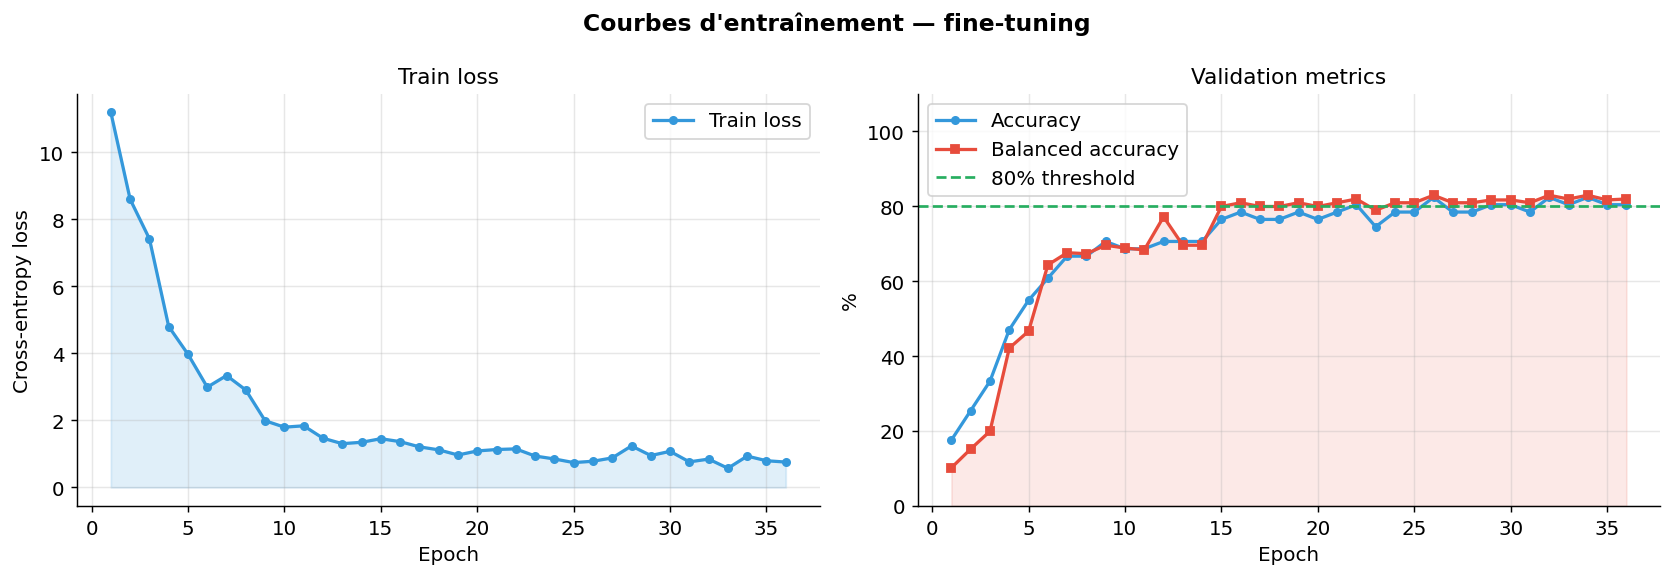

In [13]:
df_hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Courbes d\'entraînement — fine-tuning', fontweight='bold', fontsize=13)

# ── Loss ──────────────────────────────────────────────────────────────────
axes[0].fill_between(df_hist['epoch'], df_hist['train_loss'], alpha=0.15, color='#3498db')
axes[0].plot(df_hist['epoch'], df_hist['train_loss'], 'o-', color='#3498db',
             ms=4, lw=1.8, label='Train loss')
axes[0].set_title('Train loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend()

# ── Accuracy & Balanced Accuracy ──────────────────────────────────────────
axes[1].fill_between(df_hist['epoch'], df_hist['val_bal_acc']*100, alpha=0.12, color='#e74c3c')
axes[1].plot(df_hist['epoch'], df_hist['val_acc']*100,     'o-', color='#3498db',
             ms=4, lw=1.8, label='Accuracy')
axes[1].plot(df_hist['epoch'], df_hist['val_bal_acc']*100,  's-', color='#e74c3c',
             ms=4, lw=1.8, label='Balanced accuracy')
axes[1].axhline(80, color='#27ae60', ls='--', lw=1.5, label='80% threshold')
axes[1].set_ylim(0, 110)
axes[1].set_title('Validation metrics')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('%')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'finetune_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## Evaluation


In [14]:
print("Evaluating on all files...")
df_res = evaluate_on_df(df_all, ft_model)
acc, bal = print_results(df_res, "FINAL RESULTS -- confidence-weighted voting, BG augmented")

err = df_res[~df_res['correct']].copy()
err['error_type'] = err['true_class'] + ' -> ' + err['pred_class']
print("Error types:")
print(err['error_type'].value_counts().to_string())
print(f"\nMean confidence -- correct  : {df_res[df_res['correct']]['confidence'].mean():.3f}")
print(f"Mean confidence -- incorrect: {df_res[~df_res['correct']]['confidence'].mean():.3f}")

print("\n" + "─"*50)

df_res.to_csv(OUTPUT_DIR/'predictions_final.csv',index=False)
df_hist.to_csv(OUTPUT_DIR/'finetune_history_final.csv',index=False)
torch.save(ft_model.state_dict(), OUTPUT_DIR/'logmel_finetuned_final.pth')
print(f"Results saved to {OUTPUT_DIR}")


Evaluating on all files...

FINAL RESULTS -- confidence-weighted voting, BG augmented
  Accuracy : 74.8% (113/151) | Balanced : 73.0%
    BG             78%  (n=41)
    Car            74%  (n=100)
    Bus           100%  (n=5)
    Truck          40%  (n=5)

              precision    recall  f1-score   support

          BG      0.640     0.780     0.703        41
         Car      0.914     0.740     0.818       100
         Bus      0.556     1.000     0.714         5
       Truck      0.200     0.400     0.267         5

   micro avg      0.753     0.748     0.751       151
   macro avg      0.577     0.730     0.625       151
weighted avg      0.804     0.748     0.765       151

Error types:
error_type
Car -> BG       17
BG -> Car        6
Car -> Truck     6
Car -> Bus       3
BG -> Truck      2
Truck -> Car     1
Truck -> Bus     1
BG -> Tram       1
Truck -> BG      1

Mean confidence -- correct  : 0.656
Mean confidence -- incorrect: 0.505

──────────────────────────────────────

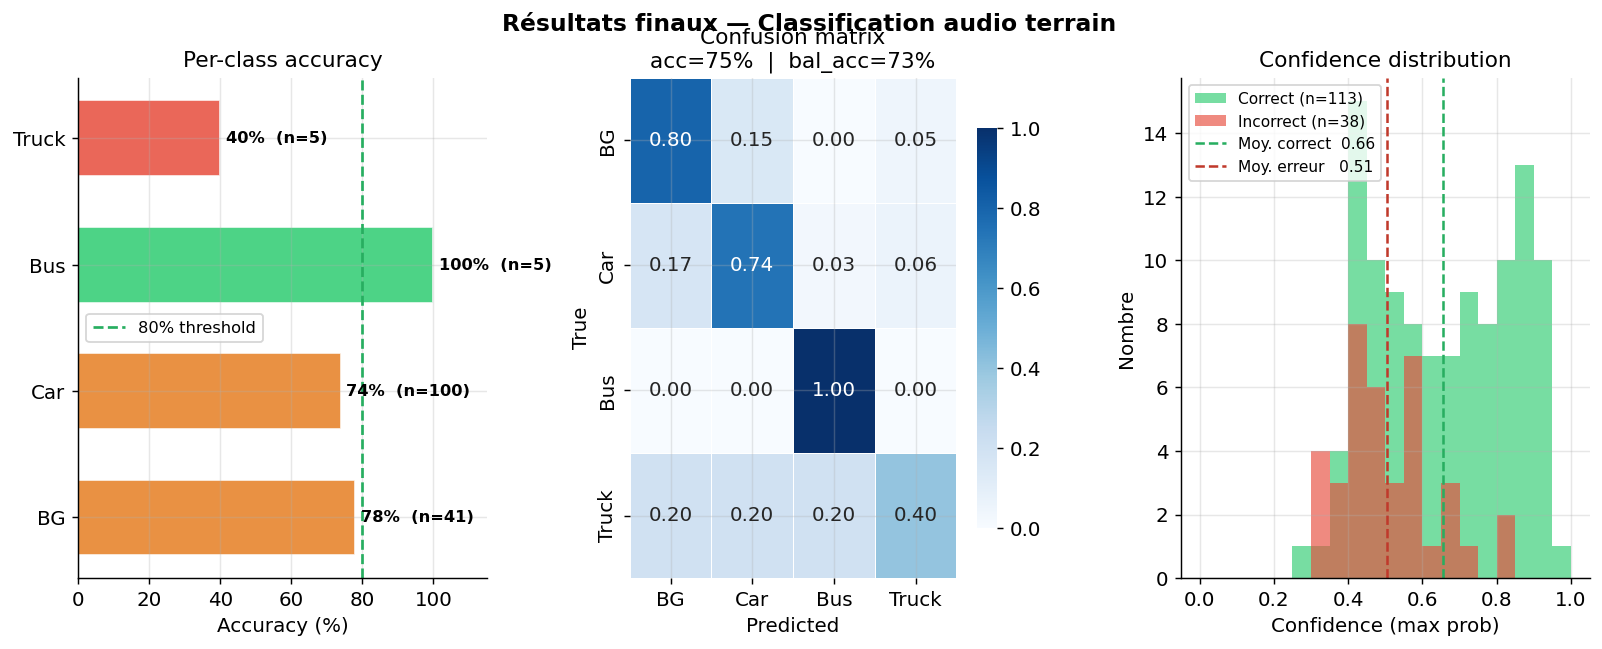

In [15]:
fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(1, 3, wspace=0.35)
fig.suptitle('Résultats finaux — Classification audio terrain', fontweight='bold', fontsize=13)

present = sorted(df_res['true_idx'].unique())
names   = [IDX2CLASS[i] for i in present]
per_cls = {cls: df_res[df_res['true_class']==cls]['correct'].mean() for cls in names}
n_cls   = {cls: len(df_res[df_res['true_class']==cls]) for cls in names}

# ── (1) Accuracy par classe ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
colors = ['#2ecc71' if v>=0.8 else '#e67e22' if v>=0.5 else '#e74c3c'
          for v in per_cls.values()]
bars = ax1.barh(list(per_cls.keys()), [v*100 for v in per_cls.values()],
                color=colors, alpha=0.85, edgecolor='white', height=0.6)
ax1.axvline(80, color='#27ae60', ls='--', lw=1.5, label='80% threshold')
ax1.set_xlim(0, 115)
ax1.set_xlabel('Accuracy (%)')
ax1.set_title('Per-class accuracy')
ax1.legend(fontsize=9)
for bar, (cls, v) in zip(bars, per_cls.items()):
    ax1.text(v*100 + 1.5, bar.get_y() + bar.get_height()/2,
             f'{v:.0%}  (n={n_cls[cls]})', va='center', fontsize=9, fontweight='bold')

# ── (2) Matrice de confusion normalisée ───────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
y_true = df_res['true_idx'].values; y_pred = df_res['pred_idx'].values
cm = confusion_matrix(y_true, y_pred, labels=present).astype(float)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=names, yticklabels=names, ax=ax2,
            vmin=0, vmax=1, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax2.set_title(f'Confusion matrix\nacc={acc:.0%}  |  bal_acc={bal:.0%}')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')

# ── (3) Distribution des confiances : correct vs incorrect ────────────────
ax3 = fig.add_subplot(gs[0, 2])
conf_ok  = df_res[df_res['correct']]['confidence']
conf_err = df_res[~df_res['correct']]['confidence']
bins = np.linspace(0, 1, 21)
ax3.hist(conf_ok,  bins=bins, alpha=0.65, color='#2ecc71', label=f'Correct (n={len(conf_ok)})')
ax3.hist(conf_err, bins=bins, alpha=0.65, color='#e74c3c', label=f'Incorrect (n={len(conf_err)})')
ax3.axvline(conf_ok.mean(),  color='#27ae60', ls='--', lw=1.4,
            label=f'Moy. correct  {conf_ok.mean():.2f}')
ax3.axvline(conf_err.mean(), color='#c0392b', ls='--', lw=1.4,
            label=f'Moy. erreur   {conf_err.mean():.2f}')
ax3.set_xlabel('Confidence (max prob)'); ax3.set_ylabel('Nombre')
ax3.set_title('Confidence distribution')
ax3.legend(fontsize=8.5)

plt.savefig(OUTPUT_DIR / 'results_final.png', dpi=150, bbox_inches='tight')
plt.show()


## Probability analysis

Distribution of `prob_BG` on true BG vs. true Car samples, and a scatter of BG/Car probability scores to identify borderline cases.


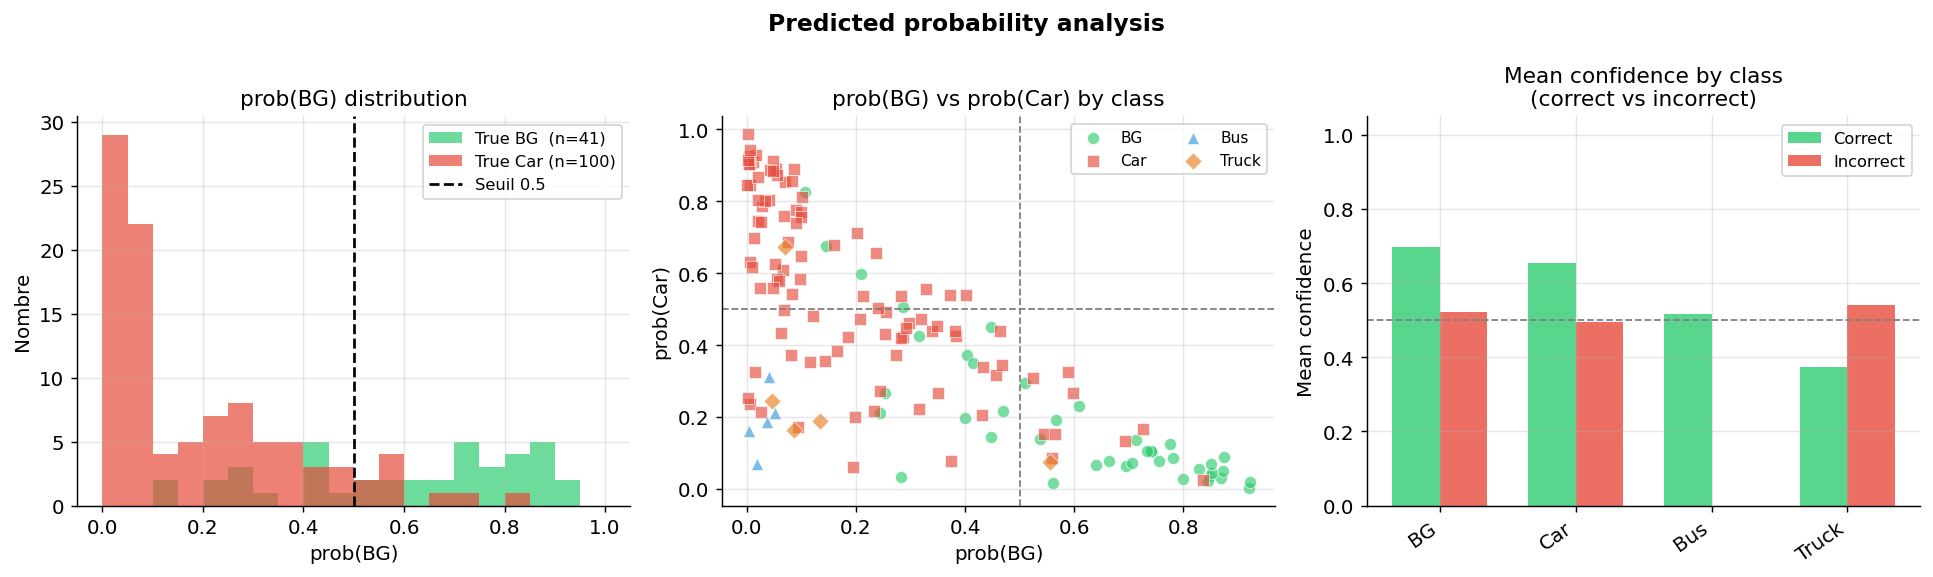


BG misclassified (9):
                    file pred_class  confidence  prob_BG  prob_Car  prob_Truck
rien_20260505_095123.wav        Car    0.826843 0.106089  0.826843    0.021259
rien_20260505_093852.wav        Car    0.676612 0.144449  0.676612    0.111539
rien_20260505_094753.wav        Car    0.598779 0.208304  0.598779    0.118053
rien_20260505_094853.wav      Truck    0.323590 0.244261  0.211134    0.323590
        electric car.wav      Truck    0.431002 0.252480  0.267024    0.431002
rien_20260430_100842.wav       Tram    0.452748 0.283394  0.032430    0.209488
rien_20260505_093652.wav        Car    0.505957 0.285897  0.505957    0.119534
rien_20260505_093152.wav        Car    0.426756 0.315861  0.426756    0.106306
rien_20260505_094022.wav        Car    0.451753 0.446808  0.451753    0.074020


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Predicted probability analysis', fontweight='bold', fontsize=13)

bg_rows  = df_res[df_res['true_class']=='BG']
car_rows = df_res[df_res['true_class']=='Car']

# ── (1) Distribution prob_BG ──────────────────────────────────────────────
bins = np.linspace(0, 1, 21)
axes[0].hist(bg_rows['prob_BG'],  bins=bins, alpha=0.7, color='#2ecc71',
             label=f'True BG  (n={len(bg_rows)})')
axes[0].hist(car_rows['prob_BG'], bins=bins, alpha=0.7, color='#e74c3c',
             label=f'True Car (n={len(car_rows)})')
axes[0].axvline(0.5, color='black', ls='--', lw=1.5, label='Seuil 0.5')
axes[0].set_xlabel('prob(BG)'); axes[0].set_ylabel('Nombre')
axes[0].set_title('prob(BG) distribution')
axes[0].legend(fontsize=9)

# ── (2) Scatter prob_BG vs prob_Car ───────────────────────────────────────
palette = {'BG':'#2ecc71','Car':'#e74c3c','Bus':'#3498db',
           'Truck':'#e67e22','MC':'#9b59b6','Tram':'#1abc9c'}
markers  = {'BG':'o','Car':'s','Bus':'^','Truck':'D','MC':'P','Tram':'X'}
for cls in names:
    sub = df_res[df_res['true_class']==cls]
    if len(sub) == 0: continue
    col = palette.get(cls, '#95a5a6')
    mks = markers.get(cls, 'o')
    axes[1].scatter(sub['prob_BG'], sub['prob_Car'],
                    c=col, marker=mks, alpha=0.65, s=45, label=cls, edgecolors='white', lw=0.5)
axes[1].axvline(0.5, color='gray', ls='--', lw=1)
axes[1].axhline(0.5, color='gray', ls='--', lw=1)
axes[1].set_xlabel('prob(BG)'); axes[1].set_ylabel('prob(Car)')
axes[1].set_title('prob(BG) vs prob(Car) by class')
axes[1].legend(fontsize=8.5, ncol=2)

# ── (3) Radar / heatmap : acc par classe (barres horizontales groupées) ───
# Confiance moyenne par classe (correct vs erreur)
cls_conf_ok  = [df_res[(df_res['true_class']==c) &  df_res['correct']]['confidence'].mean() for c in names]
cls_conf_err = [df_res[(df_res['true_class']==c) & ~df_res['correct']]['confidence'].mean() for c in names]
x = np.arange(len(names))
w = 0.35
axes[2].bar(x - w/2, cls_conf_ok,  width=w, color='#2ecc71', alpha=0.8, label='Correct')
axes[2].bar(x + w/2, cls_conf_err, width=w, color='#e74c3c', alpha=0.8, label='Incorrect')
axes[2].set_xticks(x); axes[2].set_xticklabels(names, rotation=35, ha='right')
axes[2].set_ylabel('Mean confidence')
axes[2].set_title('Mean confidence by class\n(correct vs incorrect)')
axes[2].set_ylim(0, 1.05)
axes[2].axhline(0.5, color='gray', ls='--', lw=1)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'proba_analysis_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ── BG mal classés ────────────────────────────────────────────────────────
bg_errors = df_res[(df_res['true_class']=='BG') & (~df_res['correct'])]
if len(bg_errors) > 0:
    print(f"\nBG misclassified ({len(bg_errors)}):")
    print(bg_errors[['file','pred_class','confidence','prob_BG','prob_Car','prob_Truck']]
          .sort_values('prob_BG').to_string(index=False))
else:
    print("No BG samples misclassified.")


In [17]:
# ── Final summary table ─────────────────────────────────────────────────────
print("=" * 58)
print("  SUMMARY -- Per-class metrics")
print("=" * 58)
rows_summary = []
for cls in names:
    sub = df_res[df_res['true_class'] == cls]
    ok  = sub['correct']
    rows_summary.append({
        'Class'           : cls,
        'N'               : len(sub),
        'Accuracy'        : f"{ok.mean():.1%}",
        'Conf. correct'   : f"{sub[ok]['confidence'].mean():.3f}" if ok.sum() > 0 else '-',
        'Conf. incorrect' : f"{sub[~ok]['confidence'].mean():.3f}" if (~ok).sum() > 0 else '-',
        'Flag'            : '[low]' if ok.mean() < 0.5 else ''
    })
df_summary = pd.DataFrame(rows_summary)
print(df_summary.to_string(index=False))
print("-" * 58)
print(f"  Overall  acc={acc:.1%}  |  balanced_acc={bal:.1%}")
print("=" * 58)

# ── Export ───────────────────────────────────────────────────────────────────
df_res.to_csv(OUTPUT_DIR / 'predictions_final.csv', index=False)
df_hist.to_csv(OUTPUT_DIR / 'finetune_history_final.csv', index=False)
df_summary.to_csv(OUTPUT_DIR / 'summary_final.csv', index=False)
print(f"Files saved to {OUTPUT_DIR}")


  SUMMARY -- Per-class metrics
Class   N Accuracy Conf. correct Conf. incorrect  Flag
   BG  41    78.0%         0.699           0.522      
  Car 100    74.0%         0.655           0.495      
  Bus   5   100.0%         0.518               -      
Truck   5    40.0%         0.375           0.540 [low]
----------------------------------------------------------
  Overall  acc=74.8%  |  balanced_acc=73.0%
Files saved to results_eval
